**Time Series Forecasting**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

**Load and Read Data**

In [2]:
#Load and Read file
df = pd.read_excel("/content/Exchange rates data.xlsx")

**Display Data**

In [3]:
df.shape

(318, 2)

In [4]:
df.head()

,Months,Exchange Rates
0,2000-01-01,51.770247
1,2000-02-01,51.796174
2,2000-03-01,51.791234
3,2000-04-01,51.791144
4,2000-05-01,51.797450


In [5]:

df['Months'] = pd.to_datetime(df['Months'])    # Convert Months column to datetime
df.set_index('Months', inplace=True)  # Set Months as index
ts = df['Exchange Rates'] # MS = Month Start # Use 'M' if your dates are month-end (Set time series and monthly frequency)

In [6]:
df.head()

,Exchange Rates
Months,
2000-01-01,51.770247
2000-02-01,51.796174
2000-03-01,51.791234
2000-04-01,51.791144
2000-05-01,51.797450


**Exploratory Data Analysis**

**Plot the time series**

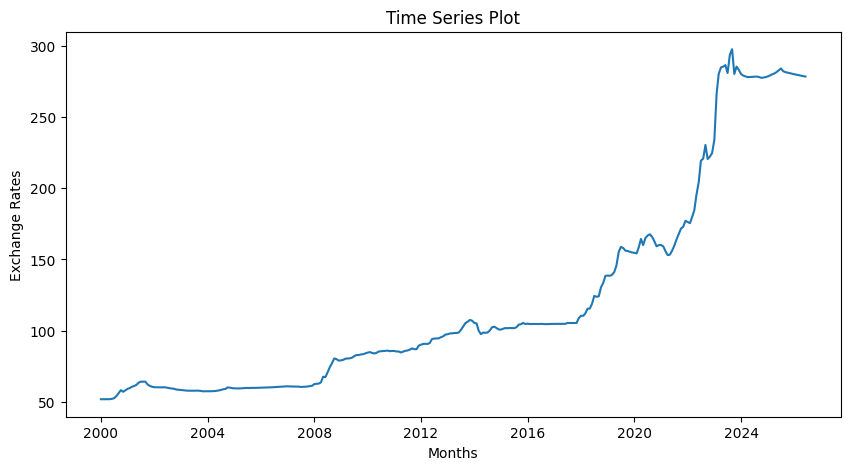

In [7]:
plt.figure(figsize=(10,5))
plt.plot(ts)
plt.title("Time Series Plot")
plt.xlabel("Months")
plt.ylabel("Exchange Rates")
plt.show()

**Check stationarity (ADF Test)**

In [8]:
result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is non-stationary")

ADF Statistic: 0.516172322350776
p-value: 0.9853564399778147
Series is non-stationary


Note: If the p-value < 0.05, the series is stationary and you can fit an ARMA model.

**Difference the series**

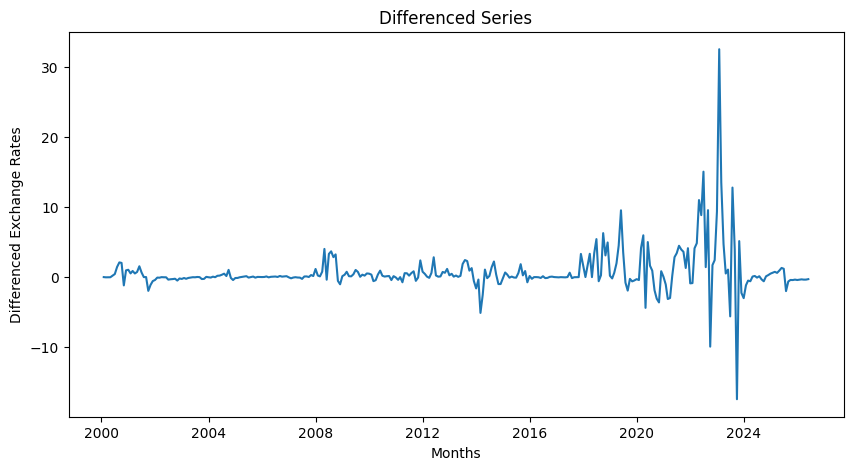

In [9]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(ts_diff)
plt.title("Differenced Series")
plt.xlabel("Months")
plt.ylabel("Differenced Exchange Rates")
plt.show()

**Decomposition**

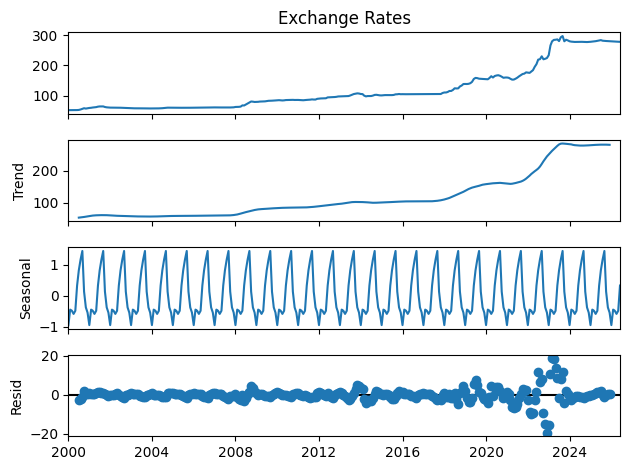

In [10]:
decomposition = seasonal_decompose(
    ts,
    model='additive',
    period=12
)

decomposition.plot()
plt.show()

**Seasonality**

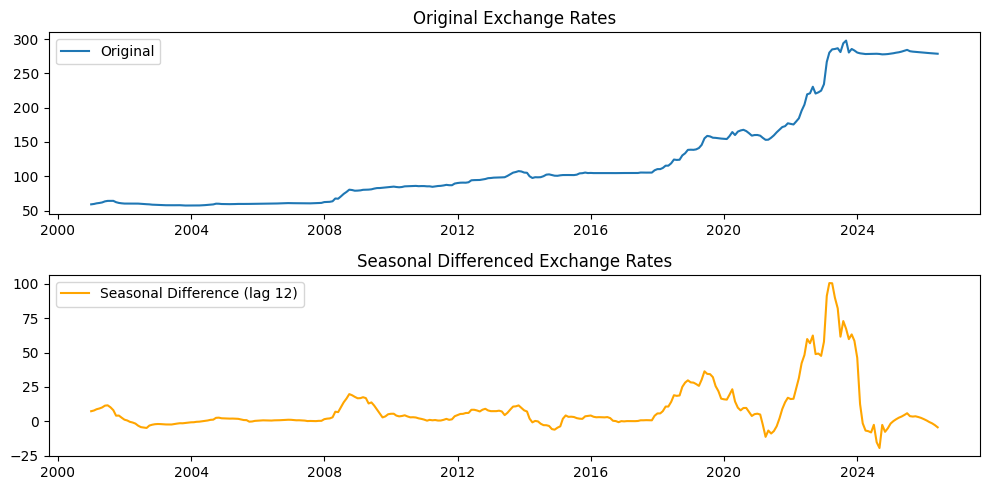

In [11]:
lagged_ts= ts.shift(12)

df['seasonal_diff'] = ts - lagged_ts

# Drop NaN values resulting from the shift. Note: This modifies the original 'df' and 'ts' in place.
df.dropna(inplace=True)

# Re-assign ts after dropping NaNs, as it's a view of df['Exchange Rates']
ts = df['Exchange Rates']

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
axes[0].plot(ts, label='Original')
axes[0].set_title('Original Exchange Rates')
axes[0].legend()

axes[1].plot(df['seasonal_diff'], label='Seasonal Difference (lag 12)', color='orange')
axes[1].set_title('Seasonal Differenced Exchange Rates')
axes[1].legend()

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

**Plot ACF and PACF**

---



In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf



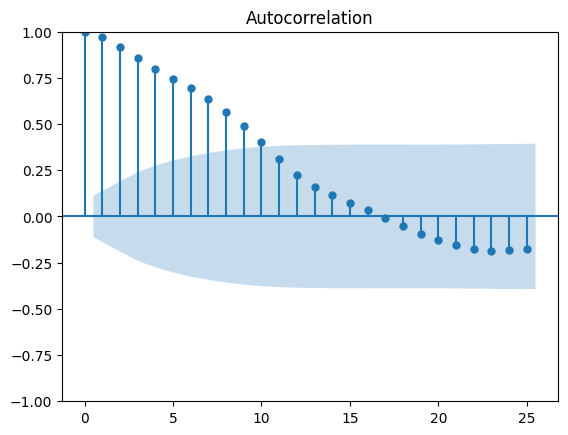

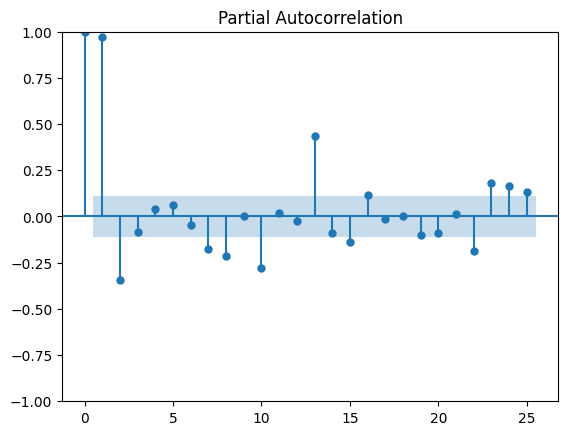

In [13]:
plot_acf(df['seasonal_diff'] )
plt.show()

plot_pacf(df['seasonal_diff'] )
plt.show()

**Fit SARIMA Model**

In [14]:
# Set monthly frequency
ts = df['Exchange Rates'].asfreq('MS')    # MS = Month Start
# Use 'M' if your dates are month-end


In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [16]:
import statsmodels.api as sm
# Ensure 'ts' is defined and has the correct frequency for SARIMAX
ts = df['Exchange Rates'].asfreq('MS')
sar = sm.tsa.statespace.SARIMAX(
    ts,
    order=(2, 1, 0),
    seasonal_order=(0, 1, 1, 12),
    trend='c').fit()
print(sar.summary())

                                      SARIMAX Results                                       
Dep. Variable:                       Exchange Rates   No. Observations:                  306
Model:             SARIMAX(2, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -756.755
Date:                              Tue, 14 Jul 2026   AIC                           1523.509
Time:                                      15:10:55   BIC                           1541.910
Sample:                                  01-01-2001   HQIC                          1530.879
                                       - 06-01-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0437      0.027      1.599      0.110      -0.010       0.097
ar.L1          0.28

**Diagnostic Checks**

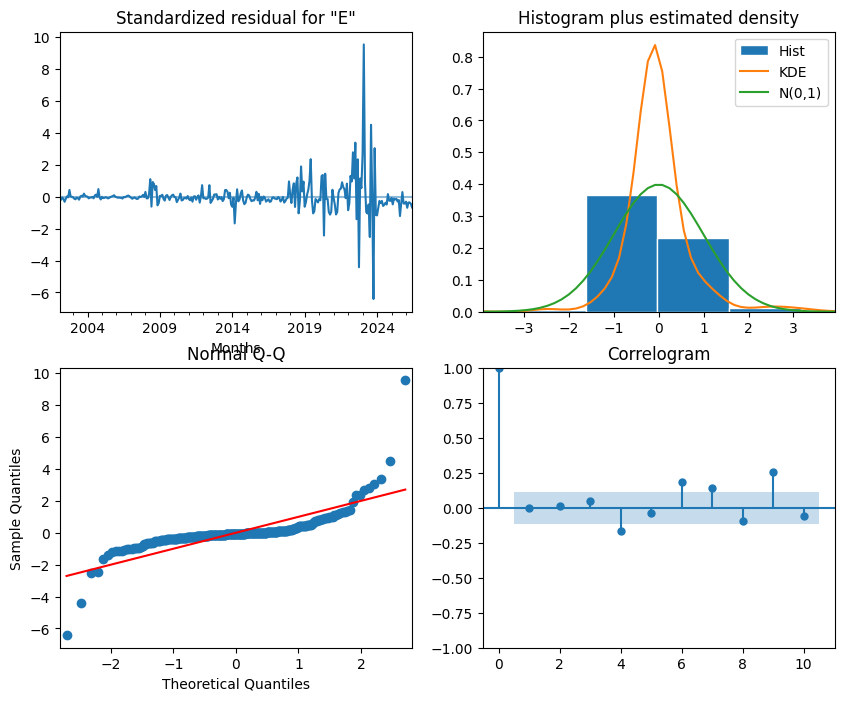

In [17]:
sar.plot_diagnostics(figsize=(10, 8))
plt.show()

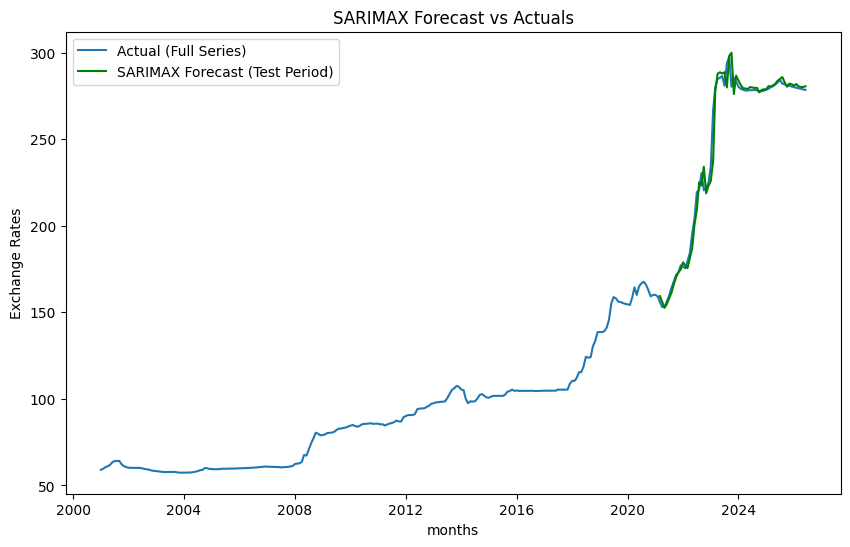

In [18]:
import matplotlib.pyplot as plt

pd.plotting.register_matplotlib_converters()

# Get predictions from the SARIMAX model
# The sar model was fitted on the entire 'ts' data.
# To compare with other models, let's get predictions for the test period.
# First, identify the start and end dates for prediction.
# Since y_test is not defined, we'll set the prediction period directly.
# This period aligns with the forecast results observed in subsequent cells.
predict_start_date = pd.Timestamp('2021-03-01')
predict_end_date = pd.Timestamp('2026-06-01')

# Get the prediction results
sar_forecast_results = sar.get_prediction(start=predict_start_date, end=predict_end_date, dynamic=False)
sar_forecast = sar_forecast_results.predicted_mean

# Plot actual values from ts and the SARIMAX forecast
plt.figure(figsize=(10, 6))
plt.plot(ts, label='Actual (Full Series)')
plt.plot(sar_forecast.index, sar_forecast, color='green', label='SARIMAX Forecast (Test Period)')
plt.title('SARIMAX Forecast vs Actuals')
plt.xlabel('months')
plt.ylabel('Exchange Rates')
plt.legend()
plt.show()

In [19]:
print(sar_forecast)

Months
2021-03-01    159.458653
2021-04-01    155.990385
2021-05-01    152.604578
2021-06-01    154.762951
2021-07-01    158.050977
                 ...    
2026-02-01    281.943363
2026-03-01    280.619363
2026-04-01    280.289432
2026-05-01    280.198258
2026-06-01    280.650424
Freq: MS, Name: predicted_mean, Length: 64, dtype: float64


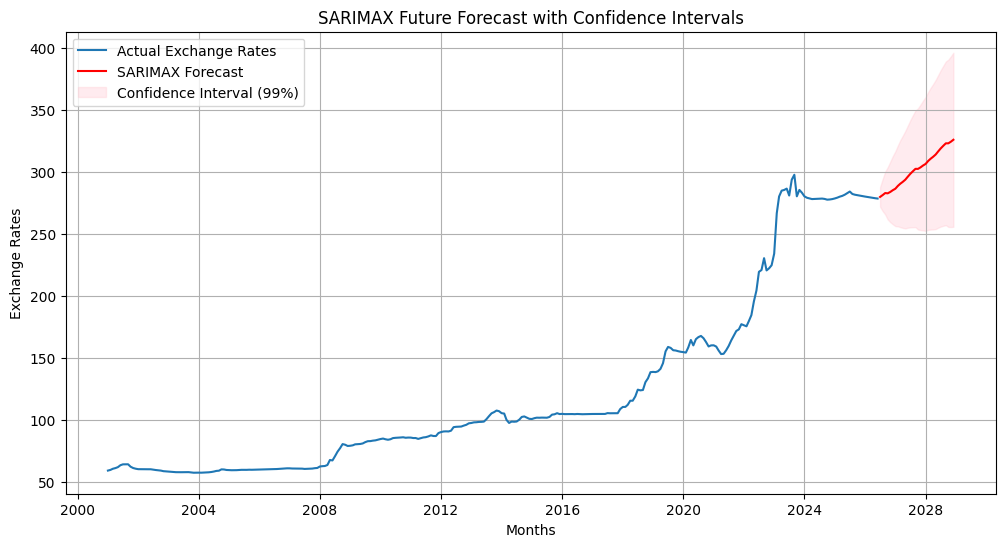

In [20]:
# can use get_forecast to create a forecast object
future_fcst = sar.get_forecast(30)

# That will have a method to pull in confidence interval
confidence_int = future_fcst.conf_int(alpha=0.01)

# Has an attribute to pull in predicted mean
fcst = future_fcst.predicted_mean

# Plot predictions and confidence intervals
plt.figure(figsize=(12, 6))
plt.plot(ts, label='Actual Exchange Rates')
plt.plot(fcst.index, fcst, color='red', label='SARIMAX Forecast')
plt.fill_between(
    confidence_int.index,
    confidence_int['lower Exchange Rates'],
    confidence_int['upper Exchange Rates'],
    color='pink', alpha=0.3, label='Confidence Interval (99%)'
)
plt.title('SARIMAX Future Forecast with Confidence Intervals')
plt.xlabel('Months')
plt.ylabel('Exchange Rates')
plt.legend()
plt.grid()
plt.show()

In [21]:
print(fcst)

2026-07-01    279.873485
2026-08-01    281.356769
2026-09-01    283.002399
2026-10-01    282.768560
2026-11-01    283.890075
2026-12-01    285.287517
2027-01-01    286.476527
2027-02-01    288.796488
2027-03-01    290.494245
2027-04-01    292.056286
2027-05-01    293.765078
2027-06-01    296.252421
2027-07-01    298.554454
2027-08-01    300.604497
2027-09-01    302.542194
2027-10-01    302.484032
2027-11-01    303.724478
2027-12-01    305.214672
2028-01-01    306.484097
2028-02-01    308.878708
2028-03-01    310.648410
2028-04-01    312.281131
2028-05-01    314.060009
2028-06-01    316.617162
2028-07-01    318.988873
2028-08-01    321.108533
2028-09-01    323.115820
2028-10-01    323.127233
2028-11-01    324.437249
2028-12-01    325.997009
Freq: MS, Name: predicted_mean, dtype: float64


**Statistical Tests**

**Ljung–Box Test (Residual Independence)**

In [22]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = sar.resid
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)

    lb_stat  lb_pvalue
10  6.53029   0.768919


**Jarque–Bera Test (Normality)**

In [23]:
from scipy.stats import jarque_bera

jb_stat, jb_pvalue = jarque_bera(residuals)

print("Jarque-Bera Statistic:", jb_stat)
print("p-value:", jb_pvalue)

Jarque-Bera Statistic: 82381.06968768865
p-value: 0.0


**ARCH Test (Homoscedasticity)**

In [24]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(residuals)

print("ARCH Statistic:", arch_test[0])
print("p-value:", arch_test[1])

ARCH Statistic: 14.563575376037505
p-value: 0.1488016335036143


**Model Evaluation**

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Evaluate the SARIMA model's in-sample performance using the training data (ts)
mse = mean_squared_error(ts, sar.fittedvalues)
mae = mean_absolute_error(ts, sar.fittedvalues)
mape = mean_absolute_percentage_error(ts, sar.fittedvalues)
print("MSE:", mse, "MAE:", mae, "MAPE:", mape*100, "%")

MSE: 23.433760549420224 MAE: 1.6932684100736781 MAPE: 1.4758394813987894 %
